# Анализ датасета

In [51]:
import os
dataset_file_name = 'data_frame_ta_consensus_sell_2026-03-24_18-02-41.csv'
dataset_file_path = os.path.abspath(f'./{dataset_file_name}')
print(dataset_file_path)

/Users/artem/PycharmProjects/ticker-analysis/jupyter/data_frame_ta_consensus_sell_2026-03-24_18-02-41.csv


In [52]:
import pandas

df = pandas.read_csv(dataset_file_path)

df

,volume,macd,rsi,tech,news,fundamental,profit,result
0,0.3,0.6,0.258334,0.0,1.0,1.0,0.0,0.992816
1,0.3,0.6,0.258334,0.0,1.0,1.0,0.0,0.992816
2,0.3,0.6,0.258334,0.0,1.0,1.0,0.0,0.818303
3,0.3,0.6,0.258334,0.0,1.0,1.0,0.0,0.818303
4,0.3,0.6,0.258334,0.0,1.0,1.0,0.0,0.240917
...,...,...,...,...,...,...,...,...
5311,0.3,0.0,0.446306,0.0,1.0,1.0,0.0,0.763144
5312,0.3,0.0,0.446306,0.0,1.0,1.0,0.0,0.794725
5313,0.3,0.0,0.446306,0.0,1.0,1.0,0.0,0.794725
5314,0.3,0.0,0.446306,0.0,1.0,1.0,0.0,0.794725


<Axes: >

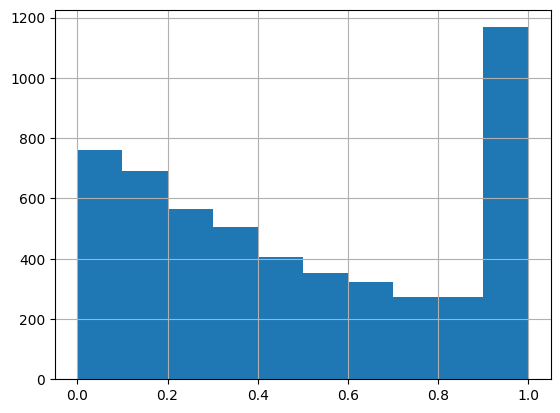

In [53]:
df['result'].hist()

In [54]:
df.isna().mean().sort_values(ascending=False).head(15)

volume         0.0
macd           0.0
rsi            0.0
tech           0.0
news           0.0
fundamental    0.0
profit         0.0
result         0.0
dtype: float64

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5316 entries, 0 to 5315
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   volume       5316 non-null   float64
 1   macd         5316 non-null   float64
 2   rsi          5316 non-null   float64
 3   tech         5316 non-null   float64
 4   news         5316 non-null   float64
 5   fundamental  5316 non-null   float64
 6   profit       5316 non-null   float64
 7   result       5316 non-null   float64
dtypes: float64(8)
memory usage: 332.4 KB


In [56]:
df.describe(include='all')

,volume,macd,rsi,tech,news,fundamental,profit,result
count,5316.000000,5316.000000,5316.000000,5316.000000,5316.000000,5316.000000,5316.0,5316.000000
mean,0.364936,0.336080,0.242447,0.047780,0.269375,0.103837,0.0,0.495504
std,0.230678,0.286366,0.270973,0.213321,0.443677,0.292805,0.0,0.344991
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000175
25%,0.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.182765
50%,0.300000,0.500000,0.146286,0.000000,0.000000,0.000000,0.0,0.426467
75%,0.300000,0.600000,0.466295,0.000000,1.000000,0.000000,0.0,0.835291
max,1.000000,0.700000,0.841248,1.000000,1.000000,1.000000,0.0,1.000000


# Подготовка данных для обучения

In [57]:
df_learn = df.copy()

x = df_learn.drop(columns=['result'])
y = df_learn['result']

x

,volume,macd,rsi,tech,news,fundamental,profit
0,0.3,0.6,0.258334,0.0,1.0,1.0,0.0
1,0.3,0.6,0.258334,0.0,1.0,1.0,0.0
2,0.3,0.6,0.258334,0.0,1.0,1.0,0.0
3,0.3,0.6,0.258334,0.0,1.0,1.0,0.0
4,0.3,0.6,0.258334,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...
5311,0.3,0.0,0.446306,0.0,1.0,1.0,0.0
5312,0.3,0.0,0.446306,0.0,1.0,1.0,0.0
5313,0.3,0.0,0.446306,0.0,1.0,1.0,0.0
5314,0.3,0.0,0.446306,0.0,1.0,1.0,0.0


In [58]:
import numpy

x_array = x.values
y_array = y.values
count_samples = len(x_array)

random_indexes = numpy.random.permutation(count_samples)

x_array = x_array[random_indexes]
y_array = y_array[random_indexes]

random_indexes

array([ 794, 4748,  550, ..., 2124, 2405, 5285])

In [59]:
train_end = int(0.7 * count_samples)
val_end = int(0.85 * count_samples)

x_train, x_val, x_test = numpy.split(x_array, [train_end, val_end])
y_train, y_val, y_test = numpy.split(y_array, [train_end, val_end])

print('X_train shape:', x_train.shape)
print('X_val shape:', x_val.shape)
print('X_test shape:', x_test.shape)

print('Y_train shape:', y_train.shape)
print('Y_val shape:', y_val.shape)
print('Y_test shape:', y_test.shape)

X_train shape: (3721, 7)
X_val shape: (797, 7)
X_test shape: (798, 7)
Y_train shape: (3721,)
Y_val shape: (797,)
Y_test shape: (798,)


In [60]:
def get_feature_names() -> list[str]:
    return [
        'volume',
        'macd',
        'rsi',
        'tech',
        'news',
        'fundamental',
        'profit',
    ]

In [61]:
import catboost

text_features = []
cat_features = []

train_pool = catboost.Pool(
    data=x_train,
    label=y_train,
    cat_features=cat_features,
    text_features=text_features,
    feature_names=get_feature_names(),
)
validate_pool = catboost.Pool(
    data=x_val,
    label=y_val,
    cat_features=cat_features,
    text_features=text_features,
    feature_names=get_feature_names(),
)
test_pool = catboost.Pool(
    data=x_test,
    label=y_test,
    cat_features=cat_features,
    text_features=text_features,
    feature_names=get_feature_names(),
)

print('TRAIN POOL', train_pool.shape)
print('VALIDATION POOL', validate_pool.shape)
print('TEST POOL', test_pool.shape)

TRAIN POOL (3721, 7)
VALIDATION POOL (797, 7)
TEST POOL (798, 7)


# Поиск оптимальных параметров обучения

In [62]:
regressor_params = {
    'task_type': 'CPU',
    'random_seed': 42,
    'verbose': 500,
    'early_stopping_rounds': 100,
    'eval_metric': 'RMSE',
    'loss_function': 'RMSE',
    'nan_mode': 'Min',
    'use_best_model': True,
}

In [ ]:
import os
import optuna
from optuna.storages import RDBStorage
from sklearn.metrics import mean_squared_error

def objective(trial):
    iterations = trial.suggest_int('iterations', 100, 10_000, step=100)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.9, step=0.001)
    depth = trial.suggest_int('depth', 3, 10, step=1)
    l2_leaf_reg = trial.suggest_int('l2_leaf_reg', 1, 10, step=1)

    params = regressor_params
    params.update(
        iterations=iterations,
        learning_rate=learning_rate,
        depth=depth,
        l2_leaf_reg=l2_leaf_reg,
        verbose=False,
    )

    trial_model = catboost.CatBoostRegressor(**params)
    
    trial_model.fit(
        train_pool,
        eval_set=validate_pool,
        plot=False,
    )
    
    return mean_squared_error(y_test, trial_model.predict(test_pool))


db_path = os.path.abspath('./db.sqlite3')
storage = RDBStorage(f'sqlite:///{db_path}')
study = optuna.create_study(storage=storage)
study.optimize(objective, n_trials=30)

study.best_params

[I 2026-02-13 13:52:36,521] A new study created in RDB with name: no-name-d2c77f01-70b2-433d-ab1a-7ff615bcfc03


# Обучение

In [63]:
params = regressor_params
params.update(
    iterations=5_000,
    learning_rate=0.01,
)

params

{'task_type': 'CPU',
 'random_seed': 42,
 'verbose': 500,
 'early_stopping_rounds': 100,
 'eval_metric': 'RMSE',
 'loss_function': 'RMSE',
 'nan_mode': 'Min',
 'use_best_model': True,
 'iterations': 5000,
 'learning_rate': 0.01}

In [64]:
model_0 = catboost.CatBoostRegressor(**params)

model_0.fit(
    train_pool,
    eval_set=validate_pool,
    plot=False,
)

0:	learn: 0.3455581	test: 0.3372455	best: 0.3372455 (0)	total: 429us	remaining: 2.15s
500:	learn: 0.3269464	test: 0.3227305	best: 0.3227305 (500)	total: 221ms	remaining: 1.98s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.3226309249
bestIteration = 689

Shrink model to first 690 iterations.


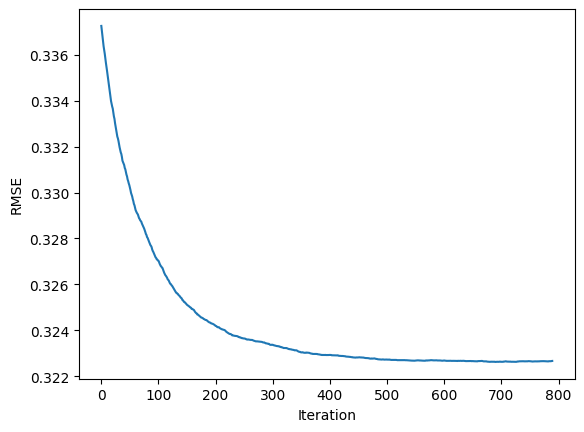

In [65]:
import matplotlib.pyplot as plt

plt.plot(model_0.get_evals_result()['validation']['RMSE'])
plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.show()

In [66]:
model_0_file_path = './ta-3_consensus_sell.cbm'
model_0.save_model(model_0_file_path)

import os

f"{os.path.getsize(model_0_file_path) / 1024 ** 2:.2f} MB"

'0.57 MB'

In [67]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, model_0.predict(test_pool))

mse

0.10993156540053606

In [68]:
import numpy as np

rmse = np.sqrt(mse)

rmse

0.33155929394383754

In [69]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, model_0.predict(test_pool))

mae

0.2905027800093928